# 1. Datenexploration - Titanic Dataset

Dieses Notebook exploriert das Titanic-Dataset und gibt einen ersten Überblick über die Daten.

## Ziele
- Dataset laden und einlesen
- Grundlegende Statistiken berechnen
- Datentypen und fehlende Werte identifizieren
- Erste Visualisierungen erstellen

In [1]:
# Import der benötigten Bibliotheken
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konfiguration für bessere Plots
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliotheken erfolgreich importiert!")

Bibliotheken erfolgreich importiert!


## 1.1 Daten laden

Lade das Titanic-Dataset aus dem `data/raw/` Verzeichnis.

In [2]:
# Dataset laden
df = pd.read_csv('../data/raw/titanic.csv')

print(f"   Dataset erfolgreich geladen!")
print(f"   Zeilen: {len(df)}")
print(f"   Spalten: {len(df.columns)}")

   Dataset erfolgreich geladen!
   Zeilen: 891
   Spalten: 15


## 1.2 Erste Inspektion

Schaue dir die ersten Zeilen, Dimensionen und Datentypen an.

In [3]:
# Erste Zeilen anzeigen
print(" Erste 5 Zeilen des Datasets:")
df.head()

 Erste 5 Zeilen des Datasets:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Informationen über das Dataset
print("\n Dataset-Informationen:")
df.info()


 Dataset-Informationen:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [5]:
# Statistische Zusammenfassung
print("\n Statistische Zusammenfassung:")
df.describe()


 Statistische Zusammenfassung:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 1.3 Fehlende Werte analysieren

Fehlende Werte pro Spalte:
deck           688
age            177
embarked         2
embark_town      2
dtype: int64


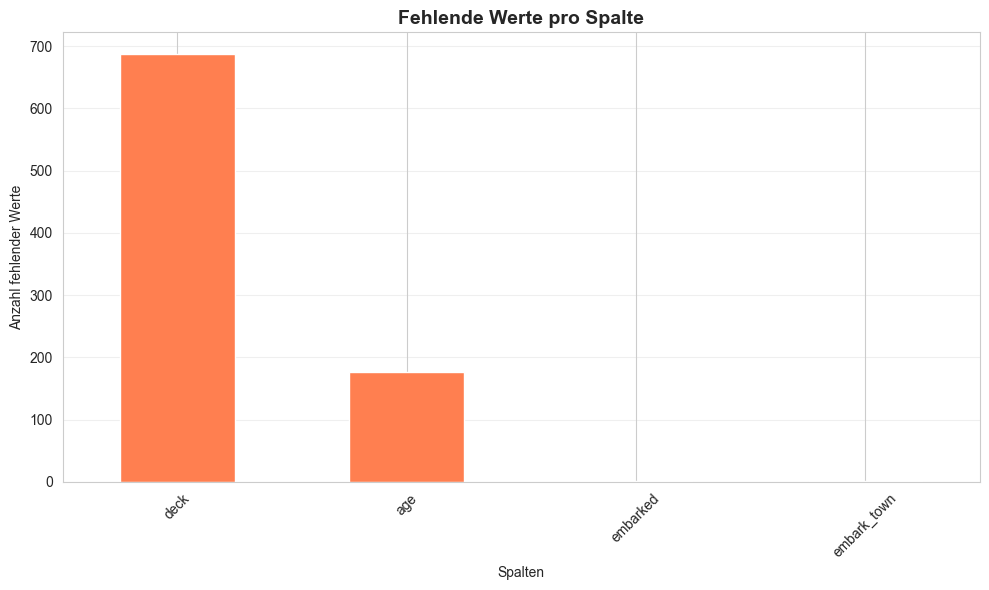

In [7]:
# Fehlende Werte analysieren und visualisieren
print("Fehlende Werte pro Spalte:")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

# Visualisierung
missing_plot = missing[missing > 0].sort_values(ascending=False)
if len(missing_plot) > 0:
    plt.figure(figsize=(10, 6))
    missing_plot.plot(kind='bar', color='coral')
    plt.title('Fehlende Werte pro Spalte', fontsize=14, fontweight='bold')
    plt.ylabel('Anzahl fehlender Werte')
    plt.xlabel('Spalten')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Keine fehlenden Werte gefunden!")

## 1.4 Erste Visualisierungen

Erstelle erste explorative Visualisierungen der wichtigsten Features.

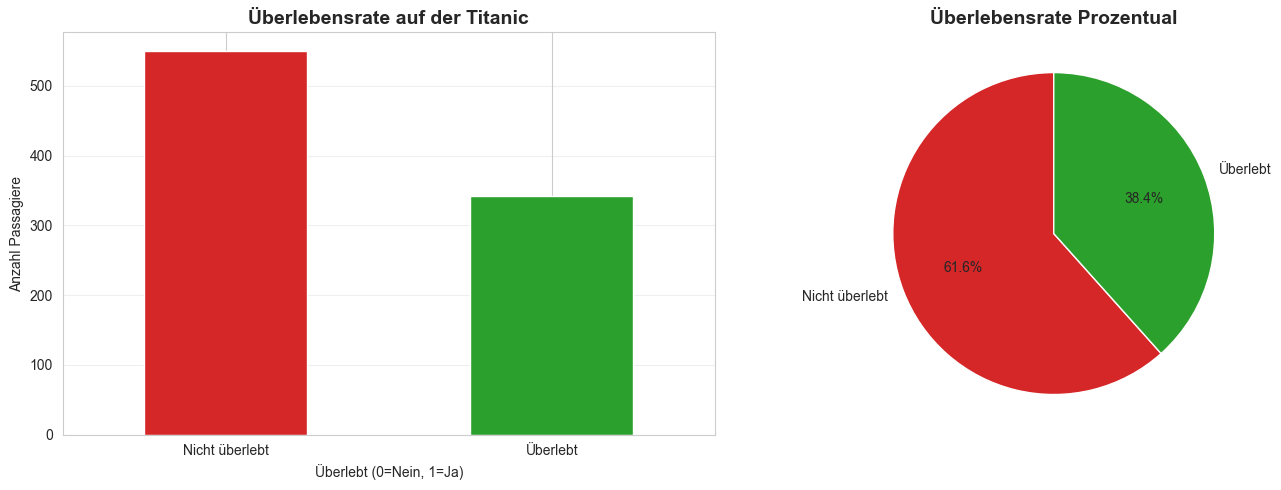


 Überlebensstatistik:
   Überlebt: 342 (38.4%)
   Nicht überlebt: 549 (61.6%)


In [8]:
# Überlebensrate visualisieren
if 'survived' in df.columns:
    survived_col = 'survived'
elif 'Survived' in df.columns:
    survived_col = 'Survived'
else:
    print(" Keine 'Survived' Spalte gefunden!")
    survived_col = None

if survived_col:
    survived_counts = df[survived_col].value_counts().sort_index()
    survival_rate = (survived_counts[1] / survived_counts.sum() * 100) if 1 in survived_counts.index else 0
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Balkendiagramm
    survived_counts.plot(kind='bar', ax=ax1, color=['#d62728', '#2ca02c'])
    ax1.set_title('Überlebensrate auf der Titanic', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Überlebt (0=Nein, 1=Ja)')
    ax1.set_ylabel('Anzahl Passagiere')
    ax1.set_xticklabels(['Nicht überlebt', 'Überlebt'], rotation=0)
    ax1.grid(axis='y', alpha=0.3)
    
    # Tortendiagramm
    ax2.pie(survived_counts, labels=['Nicht überlebt', 'Überlebt'], 
            autopct='%1.1f%%', startangle=90, colors=['#d62728', '#2ca02c'])
    ax2.set_title('Überlebensrate Prozentual', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n Überlebensstatistik:")
    print(f"   Überlebt: {survived_counts.get(1, 0)} ({survival_rate:.1f}%)")
    print(f"   Nicht überlebt: {survived_counts.get(0, 0)} ({100-survival_rate:.1f}%)")

## Nächste Schritte

Ich werde:
- Fehlende Werte behandeln
- Ausreißer identifizieren
- Features transformieren
- Daten für die Analyse vorbereiten